
FACE DETECTION SYSTEM - VIOLA-JONES

📤 Upload your image file:


Saving 3-person image.png to 3-person image.png
✓ Image uploaded: 3-person image.png
✓ Image loaded: 3-person image.png
STAGE 1: ORIGINAL IMAGE


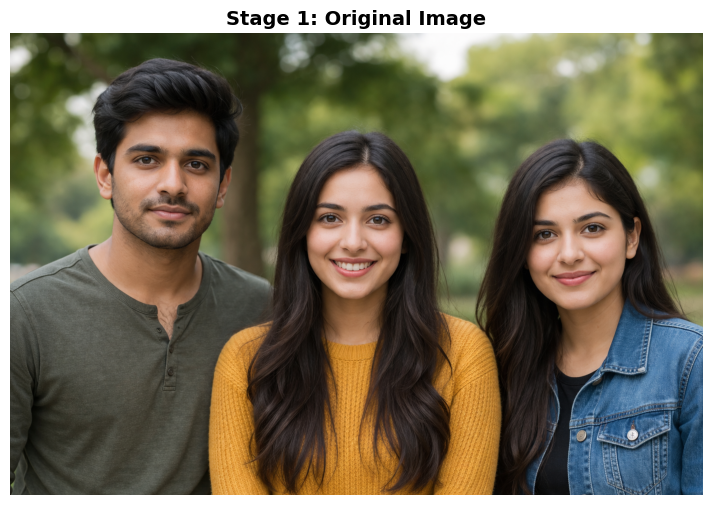

STAGE 2: GRAYSCALE


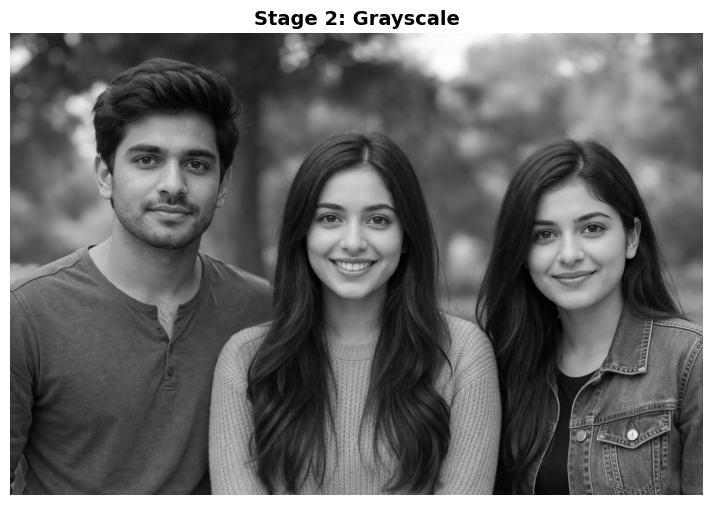

STAGE 3: INTEGRAL IMAGE


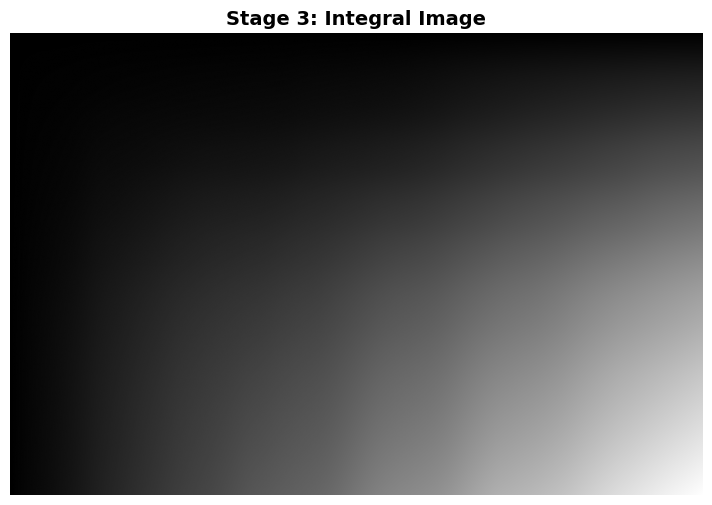

STAGE 4: HAAR FEATURES


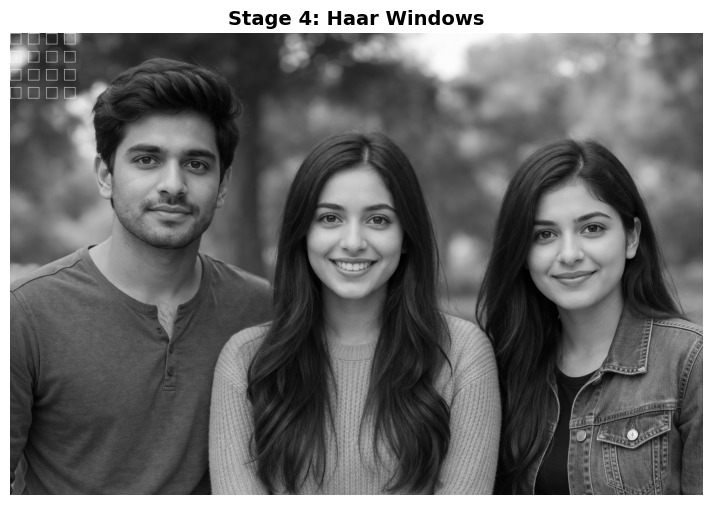

STAGE 5: CASCADE
STAGE 6: RESULT


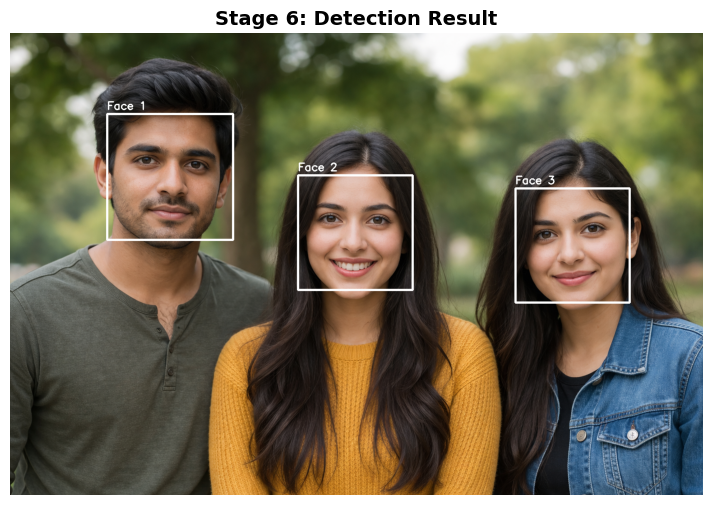

   - Faces detected: 3


In [5]:
import cv2 as c
import matplotlib.pyplot as p
import numpy as n
import os as o

print("\n" + "="*60)
print("FACE DETECTION SYSTEM - VIOLA-JONES")
print("="*60)

# Input
ip = None

try:
    from google.colab import files as f
    print("\n📤 Upload your image file:")
    up = f.upload()
    if up:
        ip = list(up.keys())[0]
        print(f"✓ Image uploaded: {ip}")
except:
    ip = input("\n📁 Enter image path (or press Enter for demo): ").strip()
    if not ip:
        ip = None

# Load image
if ip and o.path.exists(ip):
    im = c.imread(ip)
    print(f"✓ Image loaded: {ip}")
else:
    print("❌ Image not found. Using demo image...")
    im = n.ones((400, 600, 3), dtype=n.uint8) * 200
    c.circle(im, (150, 200), 60, (100, 150, 200), -1)
    c.circle(im, (450, 200), 60, (100, 150, 200), -1)
    c.circle(im, (300, 350), 60, (100, 150, 200), -1)

# ---------------- STAGE 1 ----------------
print("STAGE 1: ORIGINAL IMAGE")

p.figure(figsize=(10, 6))
p.imshow(c.cvtColor(im, c.COLOR_BGR2RGB))
p.title('Stage 1: Original Image', fontsize=14, fontweight='bold')
p.axis('off')
p.show()

# ---------------- STAGE 2 ----------------
print("STAGE 2: GRAYSCALE")

g = c.cvtColor(im, c.COLOR_BGR2GRAY)

p.figure(figsize=(10, 6))
p.imshow(g, cmap='gray')
p.title('Stage 2: Grayscale', fontsize=14, fontweight='bold')
p.axis('off')
p.show()

# ---------------- STAGE 3 ----------------
print("STAGE 3: INTEGRAL IMAGE")

ii = c.integral(g)
inn = c.normalize(ii, None, 0, 255, c.NORM_MINMAX).astype(n.uint8)

p.figure(figsize=(10, 6))
p.imshow(inn, cmap='gray')
p.title('Stage 3: Integral Image', fontsize=14, fontweight='bold')
p.axis('off')
p.show()

# ---------------- STAGE 4 ----------------
print("STAGE 4: HAAR FEATURES")

h, w = g.shape
wh, ww = 24, 24
hf = g.copy()

for y in range(0, min(h - wh, 150), 40):
    for x in range(0, min(w - ww, 150), 40):
        c.rectangle(hf, (x, y), (x + ww, y + wh), 255, 1)

p.figure(figsize=(10, 6))
p.imshow(hf, cmap='gray')
p.title('Stage 4: Haar Windows', fontsize=14, fontweight='bold')
p.axis('off')
p.show()

# ---------------- STAGE 5 ----------------
print("STAGE 5: CASCADE")

cp = c.data.haarcascades + 'haarcascade_frontalface_default.xml'
fc = c.CascadeClassifier(cp)

# ---------------- STAGE 6 ----------------
print("STAGE 6: RESULT")

fs = fc.detectMultiScale(
    g,
    scaleFactor=1.25,
    minNeighbors=8,
    minSize=(80, 80),
    maxSize=(300, 300)
)

# Advanced filtering (removes neck/false detections)
clean = []
H, W = g.shape

for (x, y, w, h) in fs:
    r = w / h

    if (
        0.8 < r < 1.25 and     # face-like shape
        y < H * 0.65 and       # avoid lower body (neck/chest)
        w > 80 and h > 80      # strong size condition
    ):
        clean.append((x, y, w, h))

fs = clean

# Draw results
ri = im.copy()
for i, (x, y, w, h) in enumerate(fs):
    c.rectangle(ri, (x, y), (x + w, y + h), (255, 255, 255), 3)
    c.putText(ri, f"Face {i+1}", (x, y - 10),
              c.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

p.figure(figsize=(10, 6))
p.imshow(c.cvtColor(ri, c.COLOR_BGR2RGB))
p.title('Stage 6: Detection Result', fontsize=14, fontweight='bold')
p.axis('off')
p.show()

print(f"   - Faces detected: {len(fs)}")